# Orientation Estimation via Template Matching
Match the real RealSense RGB capture against top-down CAD silhouette templates to estimate the azimuth orientation of the object.

Capture size: (480, 640, 3)


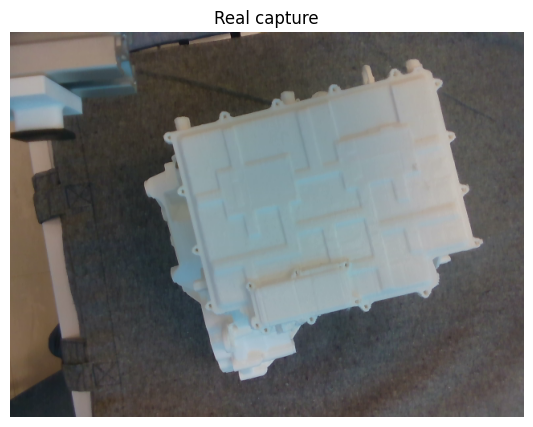

In [51]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

CAPTURE_PATH   = '../data/capture_20260331_151119_color.png'
TEMPLATES_DIR  = Path('../data/templates_topdown')
TEMPLATE_SIZE  = 256  # all templates are 256x256

img_bgr = cv2.imread(CAPTURE_PATH)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
print(f'Capture size: {img_rgb.shape}')
plt.figure(figsize=(7, 5))
plt.imshow(img_rgb)
plt.title('Real capture')
plt.axis('off')
plt.show()

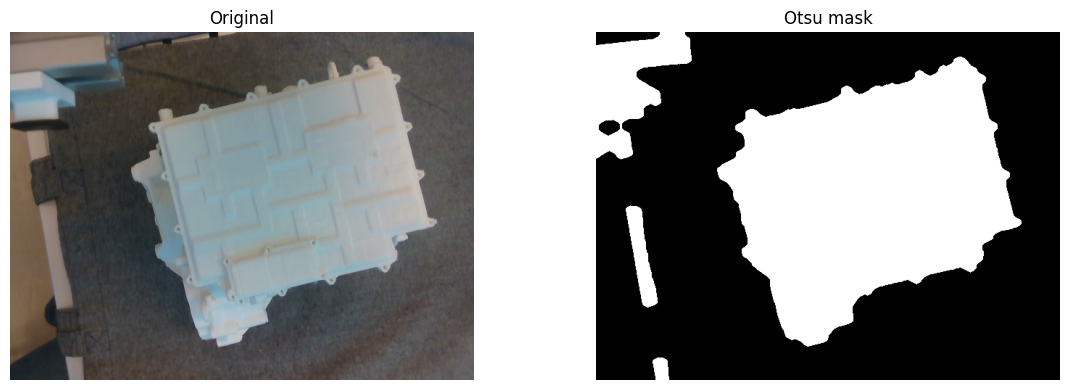

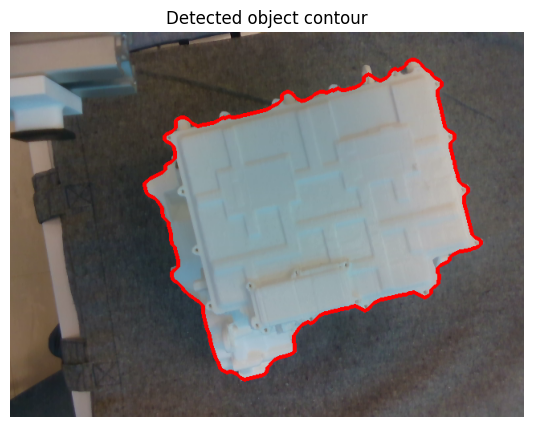

In [52]:
# --- Segment the object ---
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

_, mask_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
mask = cv2.morphologyEx(mask_otsu, cv2.MORPH_OPEN,  kernel, iterations=2)
mask = cv2.morphologyEx(mask,      cv2.MORPH_CLOSE, kernel, iterations=3)

# Largest contour defines the bounding box; we keep the full mask inside it
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
largest = max(contours, key=cv2.contourArea)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].imshow(img_rgb);           axes[0].set_title('Original');  axes[0].axis('off')
axes[1].imshow(mask, cmap='gray'); axes[1].set_title('Otsu mask'); axes[1].axis('off')
plt.tight_layout(); plt.show()

vis = img_rgb.copy()
cv2.drawContours(vis, [largest], -1, (255, 0, 0), 3)
plt.figure(figsize=(7, 5))
plt.imshow(vis)
plt.title('Detected object contour')
plt.axis('off')
plt.show()

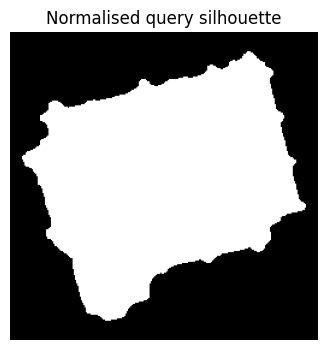

In [53]:
# --- Crop and centre-normalise the object mask ---

def contour_to_centred_mask(contour, src_mask, canvas_size=256, padding=10):
    """Render contour centred on a square canvas."""
    x, y, w, h = cv2.boundingRect(contour)
    obj_mask = np.zeros_like(src_mask)
    cv2.drawContours(obj_mask, [contour], -1, 255, thickness=cv2.FILLED)
    crop = obj_mask[y:y+h, x:x+w]

    inner = canvas_size - 2 * padding
    scale = inner / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    off_x = (canvas_size - new_w) // 2
    off_y = (canvas_size - new_h) // 2
    canvas[off_y:off_y+new_h, off_x:off_x+new_w] = resized
    return canvas

query_mask = contour_to_centred_mask(largest, merged_mask)

plt.figure(figsize=(4, 4))
plt.imshow(query_mask, cmap='gray')
plt.title('Normalised query silhouette')
plt.axis('off')
plt.show()

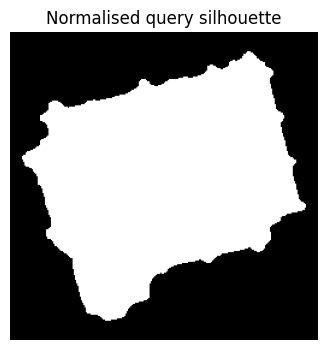

In [54]:
# --- Crop and centre-normalise the object mask ---

def contour_to_centred_mask(contour, src_mask, canvas_size=256, padding=10):
    """Crop the actual mask pixels (not a re-drawn contour) centred on a square canvas.
    This preserves protrusions and holes that the bounding contour alone would miss."""
    x, y, w, h = cv2.boundingRect(contour)
    crop = src_mask[y:y+h, x:x+w]

    inner = canvas_size - 2 * padding
    scale = inner / max(w, h)
    new_w, new_h = int(w * scale), int(h * scale)
    resized = cv2.resize(crop, (new_w, new_h), interpolation=cv2.INTER_NEAREST)

    canvas = np.zeros((canvas_size, canvas_size), dtype=np.uint8)
    off_x = (canvas_size - new_w) // 2
    off_y = (canvas_size - new_h) // 2
    canvas[off_y:off_y+new_h, off_x:off_x+new_w] = resized
    return canvas

query_mask = contour_to_centred_mask(largest, mask)

plt.figure(figsize=(4, 4))
plt.imshow(query_mask, cmap='gray')
plt.title('Normalised query silhouette')
plt.axis('off')
plt.show()

In [55]:
# --- Score all templates ---
# Templates were rendered projecting (x, y) directly to image columns/rows
# without inverting Y, which produces a bottom-up view. Flip vertically to
# match the camera's top-down perspective.

with open(TEMPLATES_DIR / 'metadata.json') as f:
    metadata = json.load(f)

def iou(a, b):
    a_bin = a > 127
    b_bin = b > 127
    inter = np.logical_and(a_bin, b_bin).sum()
    union = np.logical_or (a_bin, b_bin).sum()
    return inter / union if union > 0 else 0.0

results = []
for entry in metadata:
    az  = entry['azimuth']
    tpl_raw = cv2.imread(str(Path(entry['path'])), cv2.IMREAD_GRAYSCALE)
    tpl = cv2.flip(tpl_raw, 0)  # vertical flip: bottom-up → top-down
    results.append({'azimuth': az, 'iou': iou(query_mask, tpl), 'template': tpl})

results.sort(key=lambda r: r['iou'], reverse=True)
best = results[0]
print(f'Best match: azimuth = {best["azimuth"]}°  IoU={best["iou"]:.4f}')
print('\nTop 10:')
for r in results[:10]:
    print(f'  az={r["azimuth"]:3d}°  IoU={r["iou"]:.4f}')

Best match: azimuth = 270°  IoU=0.8209

Top 10:
  az=270°  IoU=0.8209
  az=275°  IoU=0.8017
  az=265°  IoU=0.7955
  az=280°  IoU=0.7664
  az=260°  IoU=0.7520
  az=285°  IoU=0.7476
  az= 90°  IoU=0.7299
  az= 85°  IoU=0.7228
  az=290°  IoU=0.7104
  az= 95°  IoU=0.7087


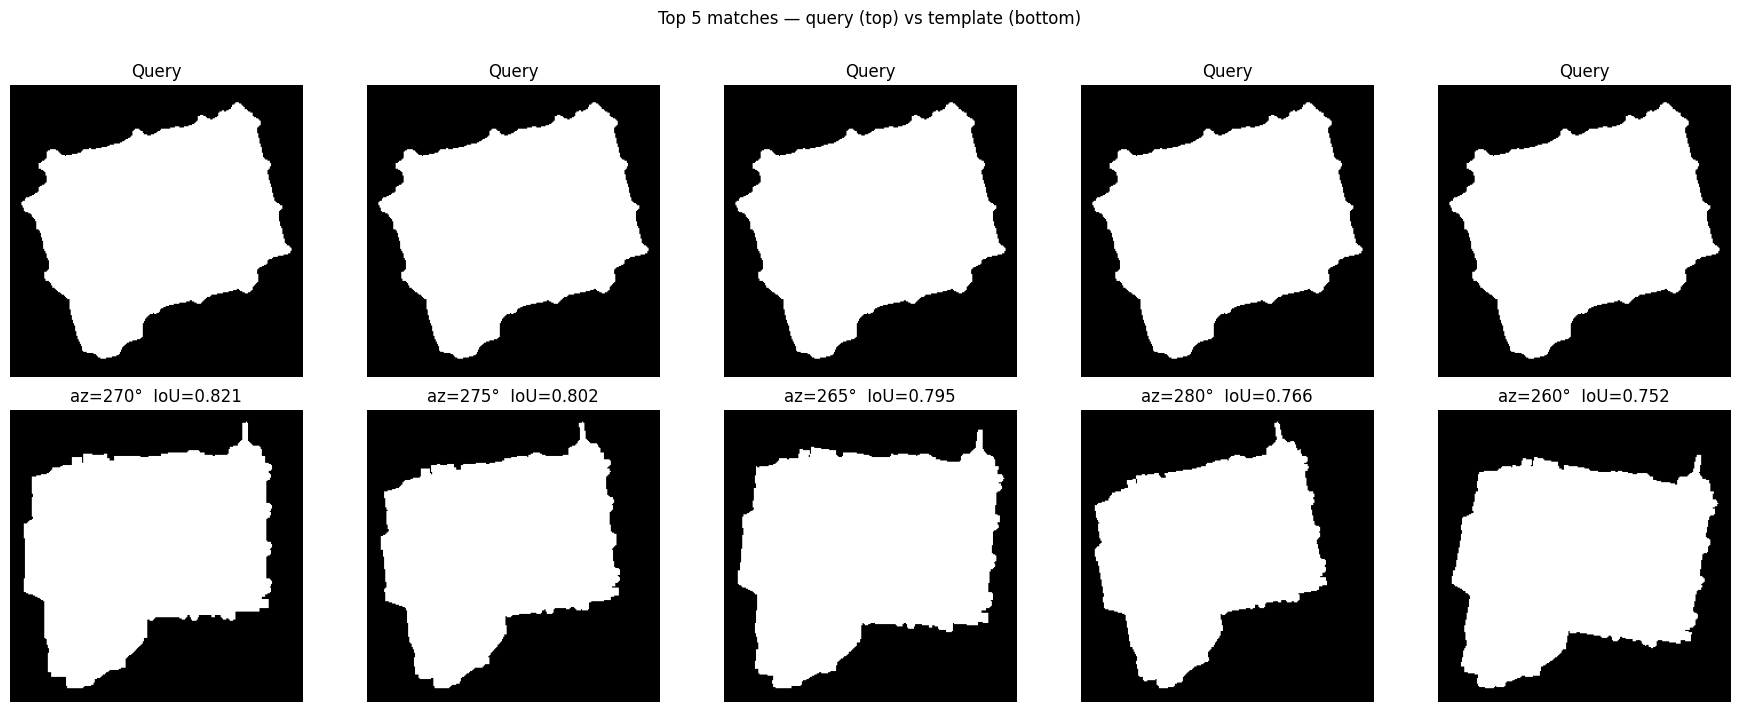

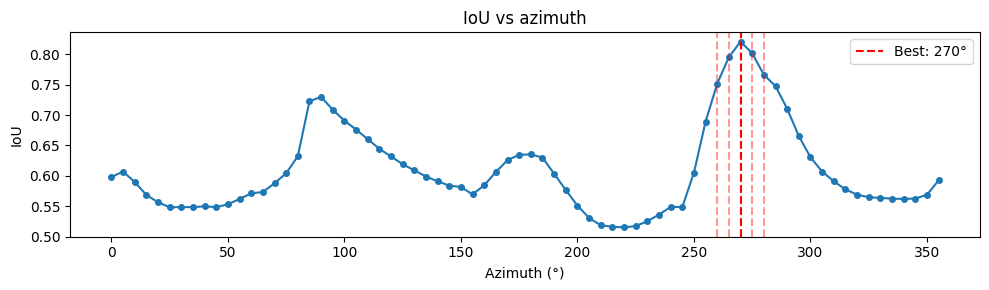

In [57]:
# --- Visualise top 5 ---

fig, axes = plt.subplots(2, 5, figsize=(18, 7))

for i, r in enumerate(results[:5]):
    axes[0, i].imshow(query_mask, cmap='gray')
    axes[0, i].set_title(f'Query')
    axes[0, i].axis('off')

    axes[1, i].imshow(r['template'], cmap='gray')
    axes[1, i].set_title(f'az={r["azimuth"]}°  IoU={r["iou"]:.3f}')
    axes[1, i].axis('off')

plt.suptitle('Top 5 matches — query (top) vs template (bottom)', y=1.01)
plt.tight_layout()
plt.show()

# IoU curve
all_sorted = sorted(results, key=lambda r: r['azimuth'])
plt.figure(figsize=(10, 3))
plt.plot([r['azimuth'] for r in all_sorted], [r['iou'] for r in all_sorted], marker='o', markersize=4)
for r in results[:5]:
    plt.axvline(r['azimuth'], color='r', alpha=0.4, linestyle='--')
plt.axvline(results[0]['azimuth'], color='r', linestyle='--', label=f'Best: {results[0]["azimuth"]}°')
plt.xlabel('Azimuth (°)'); plt.ylabel('IoU')
plt.title('IoU vs azimuth')
plt.legend(); plt.tight_layout(); plt.show()

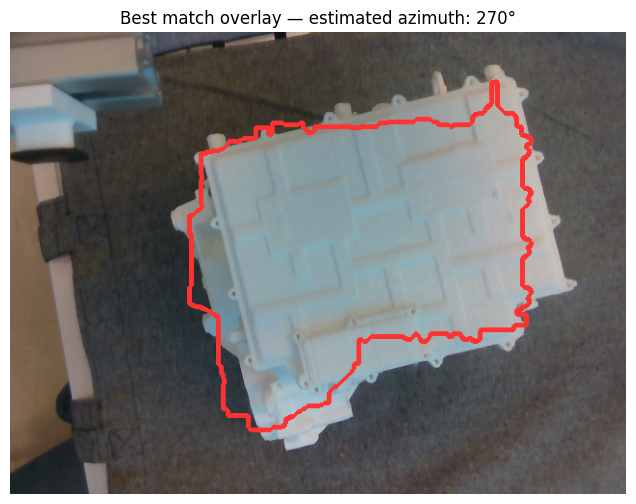

In [50]:
# --- Overlay: project best template contour onto real image ---

tpl_contours, _ = cv2.findContours(best['template'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
tpl_largest = max(tpl_contours, key=cv2.contourArea)

x, y, w, h = cv2.boundingRect(largest)
scale_x = w / TEMPLATE_SIZE
scale_y = h / TEMPLATE_SIZE
scaled = tpl_largest.astype(float).copy()
scaled[:, :, 0] = scaled[:, :, 0] * scale_x + x
scaled[:, :, 1] = scaled[:, :, 1] * scale_y + y
scaled = scaled.astype(np.int32)

overlay = img_rgb.copy()
cv2.drawContours(overlay, [scaled], -1, (255, 50, 50), 3)

plt.figure(figsize=(8, 6))
plt.imshow(overlay)
plt.title(f'Best match overlay — estimated azimuth: {best["azimuth"]}°')
plt.axis('off')
plt.show()